# Multi-Modal Tactile Material Classification — ROS2 Experimental Notebook
### Supporting material for the research paper · Student 8314923 · Daimon S2508080077

This notebook drives the experiment **through a real ROS2 (`rclpy`) pipeline** and
reproduces / extends the results reported in the paper.

**Architecture** (mirrors the COGAR design-pattern language used in the paper):

| Component | Role | ROS2 element |
|---|---|---|
| `TactileReplayPublisher` | *Sensor-Device*: replays the **real recorded** test trials, selects the peak-deformation frame, injects **synthetic** perturbations | publishes `/tactile/{rawimg,depth,deformation,shear}` |
| `FusionClassifierSubscriber` | *Computational pipeline*: re-assembles each trial, runs all 7 trained models | subscribes to the 4 topics, publishes `/tactile/predictions` |

**What the notebook does** (exactly what the assignment asks for):
1. Interact with a ROS node that *simulates the experiment* — noise levels, modality dropout, seeds are **ROS2 parameters** changed live.
2. Run multiple experimental trials (the whole test split, repeated over seeds).
3. Collect and process the data (predictions → accuracy → Mean ± Std).
4. Generate the plots used in the paper, plus the **accuracy-vs-noise** robustness plot and a **paired t-test**.

**Stated assumptions** (required by the course's reproducibility guidance):
- **A1 — relative Gaussian noise**: `sigma = noise_level · (std(modality) + eps)`, zero-mean. `noise_level` is a dimensionless knob; `0.0` = clean (reproduces the paper).
- **A2 — modality dropout**: a whole modality is zeroed (simulated dead sensor stream).
- **A3 — single specimen per class** (inherited from the dataset). Every model sees the *same* perturbed data, so the **relative fusion comparison is fair**.

> **Requirements to run:** a sourced ROS2 (Jazzy) environment with `rclpy`, plus the project files
> `models.py`, `dataset_loader.py`, `tactile_ros_nodes.py`, the recorded `dataset/`, and the trained `checkpoints/`
> all in the same folder as this notebook.

## 1 · Configuration
Set the experiment here. Switch between the two experiments by pointing at the right checkpoints and (for Experiment 1) restricting the class subset.

In [14]:
# ----------------------------- CONFIG -----------------------------
DATASET_ROOT   = "dataset"        # recorded trials: dataset/material=<name>/trial_<NNN>/
CHECKPOINT_DIR = "checkpoints"    # trained models: checkpoints/<model>_best.pt

# Experiment 2 (6 classes): CLASS_SUBSET = None
# Experiment 1 (3 classes): CLASS_SUBSET = ["apple", "orange", "kiwi"]
CLASS_SUBSET   = None

# Robustness sweep: noise levels and repeated seeds (aggregation -> Mean +/- Std)
NOISE_LEVELS   = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
SEEDS          = [0, 1, 2, 3, 4]      # used for noise > 0; noise = 0 is deterministic
SPLIT_SEED     = 42                   # same seed as training -> identical test trials

DEVICE         = "cpu"                # the trained models are tiny; CPU is fine
TRIAL_TIMEOUT  = 5.0                  # seconds to wait for a trial's prediction
# ------------------------------------------------------------------
print("Config loaded.")

Config loaded.


## 2 · Imports and ROS2 initialisation

In [15]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import ipywidgets as widgets
from IPython.display import display, clear_output

import rclpy
from rclpy.executors import SingleThreadedExecutor

from tactile_ros_nodes import (
    TactileReplayPublisher, FusionClassifierSubscriber,
    load_models, build_test_trials, MODEL_ORDER, MODALITIES,
)

warnings.filterwarnings("ignore")
sns.set_context("talk")

if not rclpy.ok():
    rclpy.init()
print("rclpy initialised:", rclpy.ok())

rclpy initialised: True


## 3 · Load the test split and the seven trained models
We rebuild the **test split with the same seed as training**, so these are the *identical* trials used in the paper — guaranteeing coherence.

In [17]:
test_trials, label_map = build_test_trials(
    DATASET_ROOT, class_subset=CLASS_SUBSET, seed=SPLIT_SEED)
classes = sorted(label_map, key=lambda k: label_map[k])
num_classes = len(classes)

print(f"Classes ({num_classes}): {classes}")
print(f"Test trials: {len(test_trials)}")
print(f"Random baseline: {1/num_classes:.3f}\n")

models = load_models(CHECKPOINT_DIR, num_classes, device=DEVICE)

Classes (6): ['apple', 'banana', 'kiwi', 'nectarine', 'orange', 'peach']
Test trials: 49
Random baseline: 0.167

  loaded rawimg (val_acc=0.7837837837837838)
  loaded depth (val_acc=0.8378378378378378)
  loaded deformation (val_acc=0.7027027027027027)
  loaded shear (val_acc=0.5945945945945946)
  loaded early_fusion (val_acc=0.8918918918918919)
  loaded late_fusion (val_acc=0.8378378378378378)
  loaded hybrid_fusion (val_acc=0.8378378378378378)


## 4 · Instantiate the ROS2 nodes and a single-threaded executor
Both nodes live in one process and one executor; the notebook drives them trial-by-trial (this is the *automatic / parameter-driven* mode the course describes).

In [18]:
publisher  = TactileReplayPublisher(label_map)
classifier = FusionClassifierSubscriber(models, num_classes, device=DEVICE)

executor = SingleThreadedExecutor()
executor.add_node(publisher)
executor.add_node(classifier)
print("Nodes up:", publisher.get_name(), "+", classifier.get_name())

Nodes up: tactile_replay_publisher + fusion_classifier


[WARN] [1780410384.184449198] [rcl.logging_rosout]: Publisher already registered for node name: 'tactile_replay_publisher'. If this is due to multiple nodes with the same name then all logs for the logger named 'tactile_replay_publisher' will go out over the existing publisher. As soon as any node with that name is destructed it will unregister the publisher, preventing any further logs for that name from being published on the rosout topic.
[WARN] [1780410384.208542385] [rcl.logging_rosout]: Publisher already registered for node name: 'fusion_classifier'. If this is due to multiple nodes with the same name then all logs for the logger named 'fusion_classifier' will go out over the existing publisher. As soon as any node with that name is destructed it will unregister the publisher, preventing any further logs for that name from being published on the rosout topic.


## 5 · The experiment driver
`run_condition` sets the ROS2 parameters (`noise_level`, `seed`, `dropout`), then publishes every test trial and spins the executor until the classifier has returned a prediction for each one. It returns a tidy DataFrame of predictions.

In [19]:
def run_condition(noise_level=0.0, seed=0, dropout="", verbose=False):
    # Live parameter change on the ROS node:
    from rclpy.parameter import Parameter
    publisher.set_parameters([
        Parameter("noise_level", Parameter.Type.DOUBLE, float(noise_level)),
        Parameter("seed",        Parameter.Type.INTEGER, int(seed)),
        Parameter("dropout",     Parameter.Type.STRING,  str(dropout)),
    ])
    classifier.reset()

    for i, td in enumerate(test_trials):
        publisher.publish_trial(td, i)
        target = i + 1
        deadline = time.time() + TRIAL_TIMEOUT
        while len(classifier.results) < target and time.time() < deadline:
            executor.spin_once(timeout_sec=0.02)
    df = pd.DataFrame(classifier.results).sort_values("trial_id").reset_index(drop=True)
    if verbose:
        print(f"  noise={noise_level} seed={seed} dropout='{dropout}' "
              f"-> {len(df)} trials classified")
    return df


def accuracies(df):
    # Per-model accuracy from a predictions DataFrame.
    return {m: float((df[m] == df["true"]).mean())
            for m in MODEL_ORDER if m in df.columns}

print("Driver ready.")

Driver ready.


## 6 · Interactive control (ipywidgets → ROS2 node)
Pick a noise level / seed / dropped modality and run a **single condition**; the bar chart shows every model's accuracy on the test split for that condition.

In [ ]:
noise_w   = widgets.FloatSlider(value=0.0, min=0.0, max=0.5, step=0.1, description="noise")
seed_w    = widgets.IntSlider(value=0, min=0, max=9, step=1, description="seed")
dropout_w = widgets.Dropdown(options=["(none)"] + MODALITIES, value="(none)", description="dropout")
run_btn   = widgets.Button(description="Run condition", button_style="primary")
out       = widgets.Output()

def _on_run(_):
    with out:
        clear_output(wait=True)
        drop = "" if dropout_w.value == "(none)" else dropout_w.value
        df = run_condition(noise_w.value, seed_w.value, drop)
        ac  c = accuracies(df)
        order = sorted(acc, key=acc.get)
        colors = ["#1f77b4" if "fusion" in m else "#7f7f7f" for m in order]
        fig, ax = plt.subplots(figsize=(8, 4.5))
        ax.barh(order, [acc[m] for m in order], color=colors)
        ax.axvline(1/num_classes, color="red", ls="--", alpha=.5,
                   label=f"random ({1/num_classes:.2f})")
        for m in order:
            ax.text(acc[m]+.01, m, f"{acc[m]:.3f}", va="center")
        ax.set_xlim(0, 1.05); ax.set_xlabel("test accuracy")
        ax.set_title(f"noise={noise_w.value}  seed={seed_w.value}  dropout='{drop or 'none'}'")
        ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

run_btn.on_click(_on_run)
display(widgets.HBox([noise_w, seed_w, dropout_w, run_btn]), out)

Output()

## 7 · Automatic sweep over noise levels (multiple seeds)
This is the core data-collection step. For every noise level we run the whole test split over several seeds, log every prediction, and save a CSV — exactly the *"run simulations automatically by changing parameters / save to a log file"* workflow from the course.

In [21]:
os.makedirs("results", exist_ok=True)
sweep_rows = []          # tidy: one row per (noise, seed, model) -> accuracy
clean_df   = None        # noise=0 predictions, for confusion matrices + bar chart

t0 = time.time()
for noise in NOISE_LEVELS:
    seeds_here = [SEEDS[0]] if noise == 0.0 else SEEDS   # noise=0 is deterministic
    for seed in seeds_here:
        df = run_condition(noise, seed)
        if noise == 0.0:
            clean_df = df.copy()
        for m, a in accuracies(df).items():
            sweep_rows.append({"noise": noise, "seed": seed, "model": m, "accuracy": a})
    print(f"noise={noise:.1f} done ({len(seeds_here)} seed(s))")

sweep = pd.DataFrame(sweep_rows)
sweep.to_csv("results/noise_sweep_log.csv", index=False)
print(f"\nSweep finished in {time.time()-t0:.1f}s — saved results/noise_sweep_log.csv")
sweep.head()

noise=0.0 done (1 seed(s))
noise=0.1 done (5 seed(s))
noise=0.2 done (5 seed(s))
noise=0.3 done (5 seed(s))
noise=0.4 done (5 seed(s))
noise=0.5 done (5 seed(s))

Sweep finished in 310.0s — saved results/noise_sweep_log.csv


,noise,seed,model,accuracy
0,0.0,0,rawimg,0.693878
1,0.0,0,depth,0.693878
2,0.0,0,deformation,0.632653
3,0.0,0,shear,0.469388
4,0.0,0,early_fusion,0.836735


## 8 · Aggregation — Mean ± Std across seeds
The course is explicit that a single run is not representative; we aggregate over seeds.

In [22]:
agg = (sweep.groupby(["model", "noise"])["accuracy"]
            .agg(["mean", "std"]).reset_index().fillna(0.0))
pivot_mean = agg.pivot(index="model", columns="noise", values="mean").reindex(MODEL_ORDER)
print("Mean accuracy (rows = model, cols = noise level):")
pivot_mean.round(3)

Mean accuracy (rows = model, cols = noise level):


noise,0.0,0.1,0.2,0.3,0.4,0.5
model,,,,,,
rawimg,0.694,0.531,0.327,0.196,0.163,0.163
depth,0.694,0.163,0.163,0.163,0.163,0.163
deformation,0.633,0.633,0.633,0.612,0.612,0.629
shear,0.469,0.461,0.449,0.449,0.449,0.469
early_fusion,0.837,0.841,0.857,0.857,0.857,0.857
late_fusion,0.735,0.788,0.743,0.559,0.453,0.335
hybrid_fusion,0.837,0.845,0.714,0.380,0.192,0.110


## 9 · Plot A — clean-data model comparison (reproduces paper Fig. 1 / 3)
Fusion vs single-modality baselines at `noise = 0`.

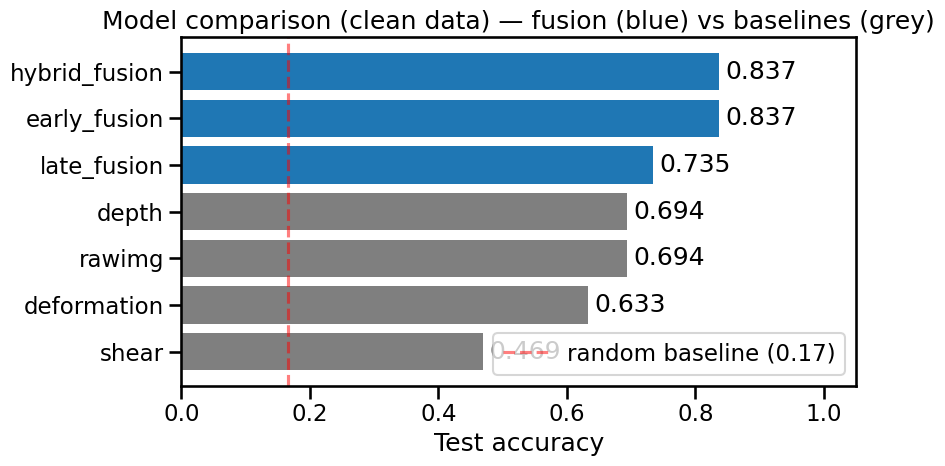

In [23]:
clean_acc = accuracies(clean_df)
order = sorted(clean_acc, key=clean_acc.get)
colors = ["#1f77b4" if "fusion" in m else "#7f7f7f" for m in order]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(order, [clean_acc[m] for m in order], color=colors)
ax.axvline(1/num_classes, color="red", ls="--", alpha=.5,
           label=f"random baseline ({1/num_classes:.2f})")
for m in order:
    ax.text(clean_acc[m]+.01, m, f"{clean_acc[m]:.3f}", va="center")
ax.set_xlim(0, 1.05); ax.set_xlabel("Test accuracy")
ax.set_title("Model comparison (clean data) — fusion (blue) vs baselines (grey)")
ax.legend(loc="lower right"); plt.tight_layout()
plt.savefig("results/nb_model_comparison.png", dpi=120, bbox_inches="tight"); plt.show()

## 10 · Plot B — confusion matrices (reproduces paper Fig. 2 / 4)
Clean-data confusion matrix for each of the seven models.

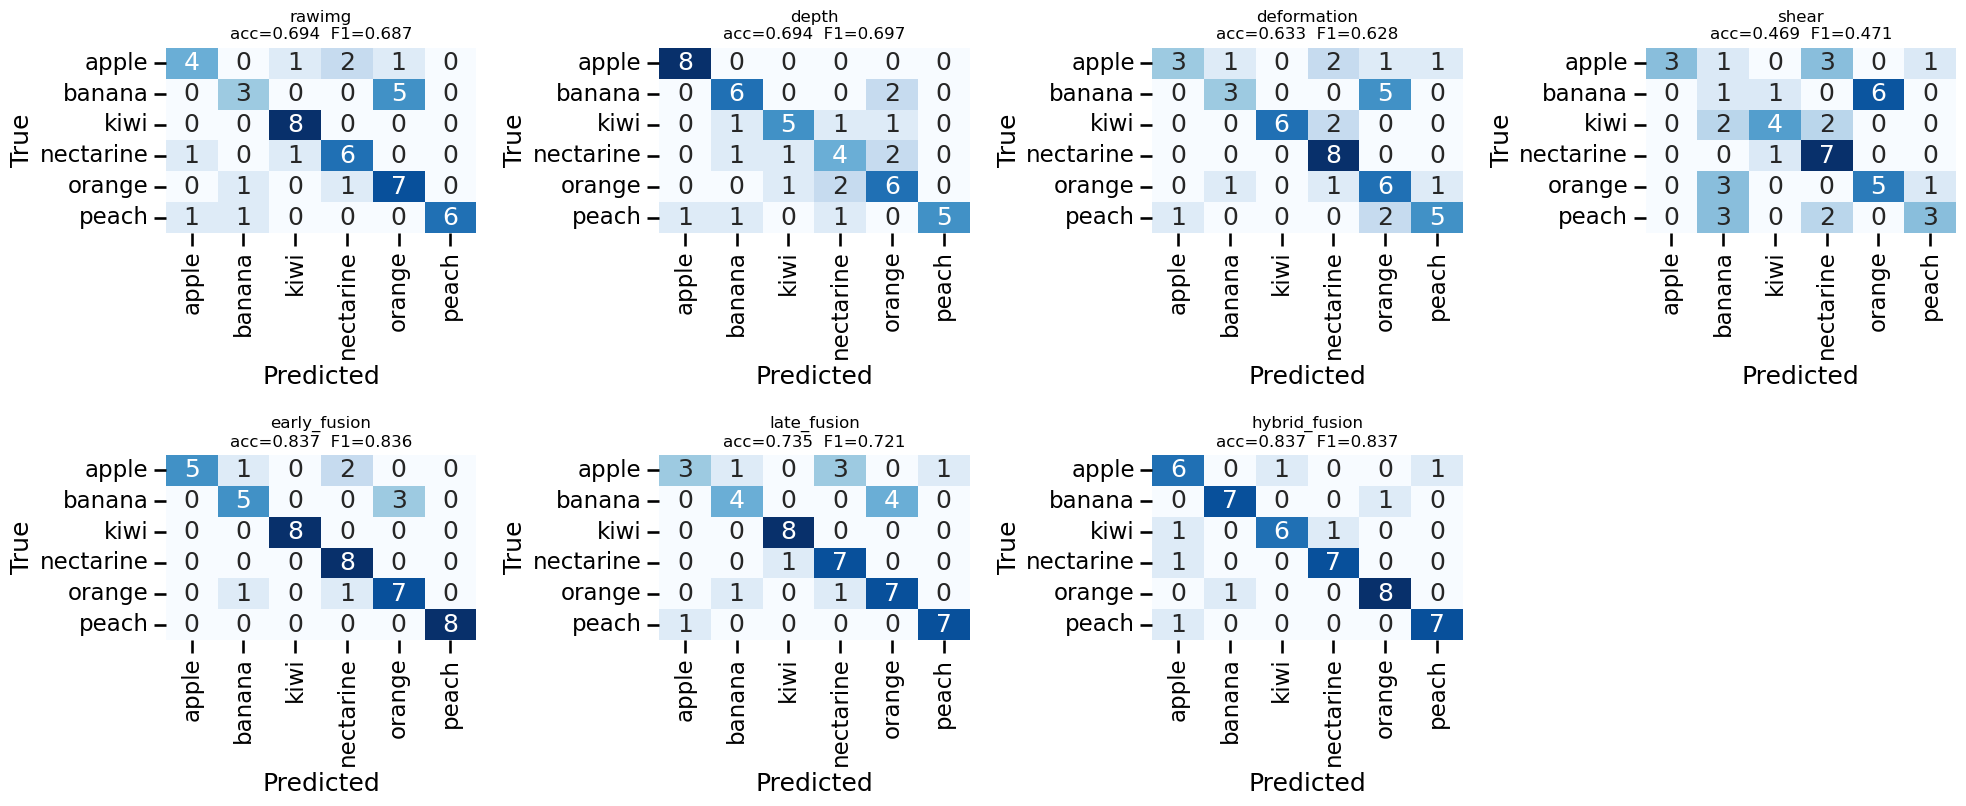

In [24]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

present = [m for m in MODEL_ORDER if m in clean_df.columns]
ncol = 4; nrow = int(np.ceil(len(present)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 4.2*nrow))
axes = np.array(axes).reshape(-1)
for ax, m in zip(axes, present):
    cm = confusion_matrix(clean_df["true"], clean_df[m], labels=list(range(num_classes)))
    acc = accuracy_score(clean_df["true"], clean_df[m])
    f1  = f1_score(clean_df["true"], clean_df[m], average="macro")
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f"{m}\nacc={acc:.3f}  F1={f1:.3f}", fontsize=12)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
for ax in axes[len(present):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig("results/nb_confusion_matrices.png", dpi=120, bbox_inches="tight"); plt.show()

## 11 · Plot C — accuracy vs noise level (the robustness result)
This is the course-recommended *"line plot showing performance vs noise level"*. Each line is a model; the shaded band / error bars are ± 1 Std across seeds. This is where the paper's central claim is stress-tested: **do the learned feature-level fusions (early, hybrid) degrade more gracefully than late fusion and the baselines as noise rises?**

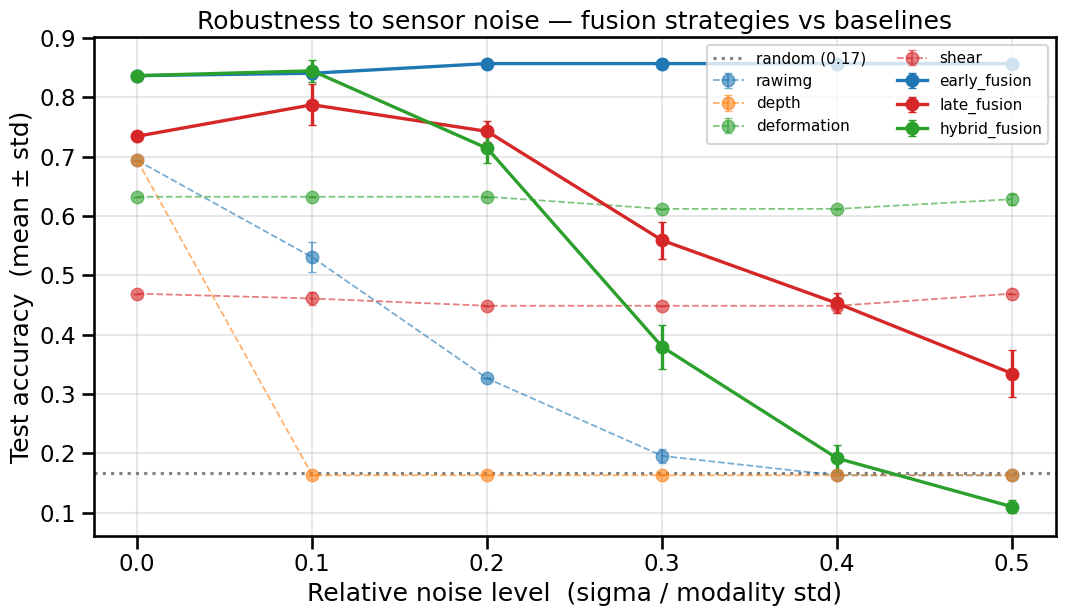

In [25]:
fig, ax = plt.subplots(figsize=(11, 6.5))
palette = {"early_fusion":"#1f77b4", "hybrid_fusion":"#2ca02c", "late_fusion":"#d62728"}
for m in MODEL_ORDER:
    sub = agg[agg["model"] == m].sort_values("noise")
    if sub.empty:
        continue
    is_fusion = "fusion" in m
    ax.errorbar(sub["noise"], sub["mean"], yerr=sub["std"],
                marker="o", capsize=3,
                lw=2.4 if is_fusion else 1.3,
                color=palette.get(m, None),
                alpha=1.0 if is_fusion else 0.6,
                ls="-" if is_fusion else "--",
                label=m)
ax.axhline(1/num_classes, color="grey", ls=":", label=f"random ({1/num_classes:.2f})")
ax.set_xlabel("Relative noise level  (sigma / modality std)")
ax.set_ylabel("Test accuracy  (mean ± std)")
ax.set_title("Robustness to sensor noise — fusion strategies vs baselines")
ax.legend(loc="upper right", fontsize=11, ncol=2); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig("results/nb_accuracy_vs_noise.png", dpi=120, bbox_inches="tight"); plt.show()

## 12 · Statistical test — paired t-test
Following the course (*"whenever possible, use the paired sample t-test"*), we compare the **best learned-fusion model** against the **best single-modality baseline** on the **same scenarios**. Each `(noise level, seed)` condition is one paired observation: both models are evaluated on the *identical* perturbed data.

- **H₀:** mean accuracy difference (fusion − baseline) = 0
- **H₁:** mean accuracy difference ≠ 0  · significance level α = 0.05

In [26]:
# Pick the best fusion model and best baseline by mean accuracy across the sweep.
mean_by_model = sweep.groupby("model")["accuracy"].mean()
fusion_models   = [m for m in MODEL_ORDER if "fusion" in m]
baseline_models = [m for m in MODEL_ORDER if "fusion" not in m]
best_fusion   = max(fusion_models,   key=lambda m: mean_by_model.get(m, -1))
best_baseline = max(baseline_models, key=lambda m: mean_by_model.get(m, -1))

# Build paired vectors over identical (noise, seed) scenarios.
key = ["noise", "seed"]
fa = sweep[sweep.model == best_fusion ].set_index(key)["accuracy"]
ba = sweep[sweep.model == best_baseline].set_index(key)["accuracy"]
paired = pd.concat([fa, ba], axis=1, keys=["fusion", "baseline"]).dropna()

t_stat, p_val = stats.ttest_rel(paired["fusion"], paired["baseline"])
mean_diff = (paired["fusion"] - paired["baseline"]).mean()

print(f"Best fusion model   : {best_fusion}   (mean acc {mean_by_model[best_fusion]:.3f})")
print(f"Best baseline model : {best_baseline} (mean acc {mean_by_model[best_baseline]:.3f})")
print(f"Paired scenarios (n): {len(paired)}")
print(f"Mean difference     : {mean_diff:+.3f}")
print(f"t-statistic         : {t_stat:.3f}")
print(f"p-value             : {p_val:.4f}")
print("-"*48)
if p_val < 0.05:
    print(f"p < 0.05  ->  REJECT H0: {best_fusion} differs significantly from {best_baseline}.")
else:
    print(f"p >= 0.05 ->  fail to reject H0: no significant difference detected.")

Best fusion model   : early_fusion   (mean acc 0.853)
Best baseline model : deformation (mean acc 0.624)
Paired scenarios (n): 26
Mean difference     : +0.229
t-statistic         : 74.896
p-value             : 0.0000
------------------------------------------------
p < 0.05  ->  REJECT H0: early_fusion differs significantly from deformation.


## 13 · How to run / reproducibility / packaging

**Reproducibility (course checklist):**
- *Hardware*: Daimon S2508080077 GelSight-style optical tactile sensor (data recorded offline).
- *Software stack*: ROS2 Jazzy + `rclpy`, PyTorch, scikit-learn, NumPy/Pandas, Matplotlib/Seaborn.
- *Seeds*: split seed `42` (identical to training); noise seeds `{0..4}`; per-trial noise RNG is `seed·1e5 + trial_id`.
- *Protocol*: replay test split → inject relative Gaussian noise (A1) / dropout (A2) → classify with all 7 models → aggregate Mean ± Std over seeds.

**Optional — wrap the nodes as a proper ROS2 package** (`ament_python`) so they also run via `ros2 run`:

```
tactile_fusion_ros/
├── package.xml
├── setup.py
└── tactile_fusion_ros/
    ├── __init__.py
    └── nodes.py        # the contents of tactile_ros_nodes.py
```
`setup.py` entry points:
```python
entry_points={"console_scripts": [
    "replay = tactile_fusion_ros.nodes:main_publisher",
    "classifier = tactile_fusion_ros.nodes:main_classifier",
]}
```

**Coherence with the paper:** at `noise = 0` Plots A and B reproduce the paper's Fig. 1–4 exactly (same test split, same checkpoints). Plot C and the paired t-test operationalise the robustness study the paper named as future work (*noise injection, modality dropout*).

## 14 · Shutdown
Destroy the nodes and shut down rclpy cleanly.

In [27]:
executor.remove_node(publisher)
executor.remove_node(classifier)
publisher.destroy_node()
classifier.destroy_node()
if rclpy.ok():
    rclpy.shutdown()
print("ROS2 shut down cleanly.")

ROS2 shut down cleanly.
